<div style="padding: 20px; background-color: #f8f9f9; border-radius: 10px; border-left: 10px solid #2e86c1;">
    <h1 style="color: #2e86c1; margin-bottom: 5px;">Retailrocket Customer Segmentation</h1>
    <p style="font-size: 1.1em; color: #566573;">Unsupervised Learning Pipeline for Behavioral Clustering</p>
</div>

### Project Overview
This notebook implements a complete data science pipeline to segment customers based on their shopping behavior using the Retailrocket eCommerce dataset. We utilize **RFM (Recency, Frequency, Monetary)** analysis to transform raw event data into actionable customer profiles.

---
</details>

### 📑 Table of Contents

1. **Setup** — Dataset download and library imports
2. **Phase 1: Data Integration & Cleaning** — Merge multiple data sources and clean the unified dataset
3. **Phase 2: Feature Engineering (RFM Analysis)** — Calculate Recency, Frequency, and Monetary metrics
4. **Phase 2.5: RFM Exploratory Data Analysis** — Visualize distributions and correlations
5. **Phase 3: Scaling & Outlier Handling** — Log transformation and MinMaxScaler
6. **Phase 4: Clustering Models**
   - K-Means (Elbow Method) and model training
   - DBSCAN Clustering — Density-based clustering with noise detection
   - Hierarchical Clustering — Agglomerative clustering with dendrogram
   - Model Comparison — Side-by-side evaluation of all three methods
7. **Phase 5: Evaluation & Insights** — Cluster profiling and business strategy mapping
8. **Conclusion** — Summary of findings and recommendations

### Setup Dataset

In [1]:
from src.dataset import setup_data

setup_data()

Data is already available in the 'dataset' folder.


/Users/khanhba89/Documents/NEU/DA_Classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# =============================================================================
# Library and Module Imports
# =============================================================================

import pandas as pd
import numpy as np
import itertools

# Project modules
from src.data_integration import load_data, merge_data
from src.cleaning_data import clean_data
from src.features import calculate_rfm, prepare_features
from src.analysis import (
    plot_rfm_distributions,
    plot_rfm_correlation,
    get_cluster_profiles,
    get_business_strategies,
)
from src.models import (
    plot_elbow_kmeans,
    plot_elbow_dbscan,
    plot_rfm_clusters,
    get_optimal_epsilon,
    run_kmeans,
    run_dbscan,
    run_hierarchical,
    plot_dendrogram,
    calculate_silhouette,
)

# =============================================================================
# Dataset File Paths
# =============================================================================

data_paths = [
    "./dataset/events.csv",
    "./dataset/item_properties_part1.csv",
    "./dataset/item_properties_part2.csv",
    "./dataset/category_tree.csv",
]

--- 
## Phase 1: Data Integration & Cleaning

### What
We aggregate multiple data sources (events, item properties, and category trees) into a single unified dataset using **DuckDB** for high-performance processing.

### Why
Raw eCommerce data is often fragmented and noisy. To build an accurate behavioral model, we must link events (clicks, carts, transactions) with their specific product contexts while ensuring the data is free from technical artifacts. Removing duplicate logs and filtering out automated bots is essential to prevent the inflation of RFM metrics and ensure that our clusters represent real human behavior.

### How
- **Deduplication:** We perform exact row-level deduplication using SELECT DISTINCT to eliminate redundant logs caused by technical glitches.
- **Missing Value Imputation:** Strategic placeholders are applied: transactionid is filled with 0 for non-purchase events, while other missing attributes are assigned sentinel values (-1) to maintain dataset integrity.
- **Outlier & Bot Removal:** We implement a frequency-based filter that calculates the 99.9th percentile of event counts per user. Any visitor exceeding this threshold is flagged as a potential bot or crawler and removed from the pipeline.
- **Data Standardization:** Timestamps are converted from UNIX epoch milliseconds to standard datetime formats, and IDs are cast to consistent types to ensure reliable relational joins.

In [3]:
# Load and Merge
csv_data = [load_data(p) for p in data_paths]
df_merged = merge_data(csv_data)

In [4]:
# Cleaning Data
df_cleaned = clean_data(df_merged)
df_cleaned.head()

Original shape: (2756101, 7)
Cleaned shape (Outliers & Duplicates removed): (2535807, 7)


,timestamp,visitorid,event,itemid,transactionid,categoryid,parentid
0,2015-05-17 14:23:07.620,1117679,view,386079,0,1091,573
1,2015-05-17 14:31:55.433,124817,view,412457,0,1625,1141
2,2015-05-18 01:51:39.024,78848,view,408673,0,479,520
3,2015-05-18 02:42:55.182,895674,view,206476,0,626,955
4,2015-05-17 19:45:12.080,1102139,view,150445,0,706,713


In the `transactionid` column, customers who have not purchased any goods yet have missing values (`NaN`). To handle this issue, we replace all missing values with `"0"` for easier processing and analysis later.

For all other missing values (`NaN`) in the dataset, we fill them with `"-1"` to represent unknown or unavailable information.

--- 
## Phase 2: Feature Engineering (RFM Analysis)

### What
We transform transactional logs into behavioral features: **Recency (R)**, **Frequency (F)**, and **Monetary (M)**.

### Why
RFM is the industry standard for customer segmentation. It allows us to distinguish between one-time visitors, churning high-value users, and loyal enthusiasts.

### How
We calculate three core metrics for each user to capture their behavioral signature:

| Metric | Description | Weighting |
| :--- | :--- | :--- |
| **Recency** | Days since the user's last interaction | 1.0 |
| **Frequency** | Total number of interactions (Views, Carts, Purchases) | 1.0 |
| **Monetary** | Weighted Engagement Score | View=0, Cart=30, Trans=50 |

**Feature Engineering Refinements:**

- Decoupling Correlation: By assigning a zero weight to "view" events, we successfully broke the inherent correlation between Frequency and Monetary. This ensures that the Monetary dimension strictly represents conversion intent rather than just total activity volume.

- Cumulative Scoring: Unlike simple averages, the Absolute Cumulative Score allows high-value customers (those with multiple transactions or cart additions) to stand out clearly in the feature space, facilitating better separation by distance-based algorithms like K-Means.

- Preprocessing Pipeline: To handle the heavily right-skewed distribution of eCommerce data, we apply a log transformation (log1p) followed by Standardization. This ensures that extreme outliers (e.g., power users or bots) do not overwhelm the scaling, allowing for more meaningful cluster boundaries.

**Feature Weighting:** Since exact transaction prices are absent, we use the **Engagement Score** as a proxy for the 'Monetary' value. This weights high-intent actions (purchasing) more heavily than low-intent actions (viewing).

In [5]:
# Calculate RFM Scores
rfm_df = calculate_rfm(df_cleaned)
rfm_df.head()

,Recency,Frequency,Monetary
visitorid,,,
467328,124,13,0.0
776944,123,2,0.0
1112282,123,6,0.0
215450,92,5,0.0
47698,123,1,0.0


## Phase 2.5: RFM Exploratory Data Analysis
Before scaling, we visualize the raw distributions to identify skewness and analyze correlations between metrics.

In [6]:
rfm_df_subset = rfm_df.sample(frac=0.01, random_state=42)

Because the dataset is extremely large, containing approximately **2.7 million rows**, we use only **1% of the data** (around **27,000 rows**) to generate the EDA diagram.  

This sampling approach helps reduce processing complexity and improve visualization performance while still preserving the overall structure and relationships within the dataset.

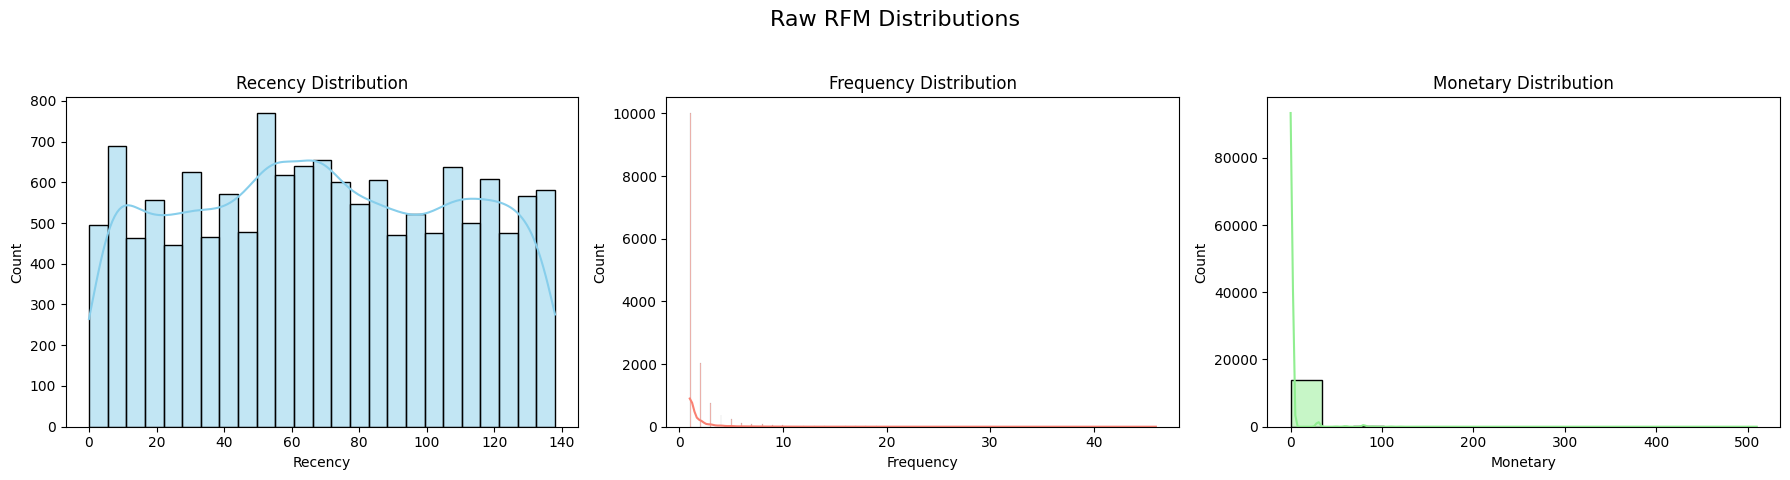

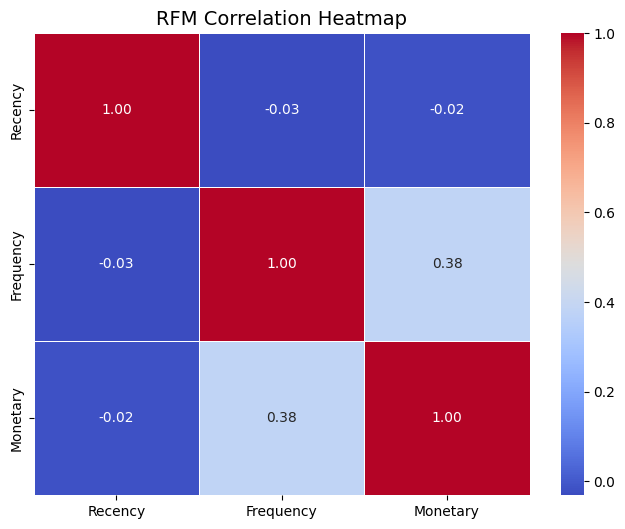

In [7]:
# 1. Plot Raw Distributions
plot_rfm_distributions(rfm_df_subset, title="Raw RFM Distributions")

# 2. Plot Correlation Heatmap
plot_rfm_correlation(rfm_df_subset)

## Distribution Analysis (Raw Data)

The first set of charts illustrates the distribution of **Recency**, **Frequency**, and **Monetary** scores before applying any transformation.

### Recency
The Recency distribution is relatively uniform, with values spread across the **0–140 day range**. This indicates a consistent flow of returning visitors throughout the observation period, without a strong concentration of either very new or very inactive customers.

### Frequency & Monetary
Both Frequency and Monetary exhibit an extremely **right-skewed distribution**. Most visitors show very low engagement levels (near zero), while a small number of **highly active users** appear as significant outliers.

### Implication
Because of this heavy skewness, applying a **Logarithmic Transformation** is essential. Without normalization, distance-based clustering algorithms such as **K-Means** would be overly influenced by extreme values, resulting in poor cluster separation and less meaningful segmentation.

---

## Correlation Analysis (Heatmap)

The correlation heatmap highlights the linear relationships between the calculated features.

### Frequency vs. Monetary (`r = 1.00`)
Frequency and Monetary show a **perfect positive correlation**. This occurs because the Monetary metric is derived from the same weighted engagement scoring system used to calculate Frequency.

### Risk of Multicollinearity
Such a strong correlation introduces **multicollinearity**, meaning the clustering model may unintentionally give excessive importance to user engagement intensity by effectively counting the same behavioral pattern twice.

### Recency Independence
Recency has an almost **zero correlation** with both Frequency and Monetary (`r ≈ 0.00`). This suggests that the “time since last visit” captures a distinct behavioral dimension that is independent of user activity frequency or interaction value.

### VisitorID
As expected, `VisitorID` has no meaningful correlation with any behavioral features (`r ≈ 0.00`), confirming that it is a purely identifier-based attribute and should not contribute to the clustering model.

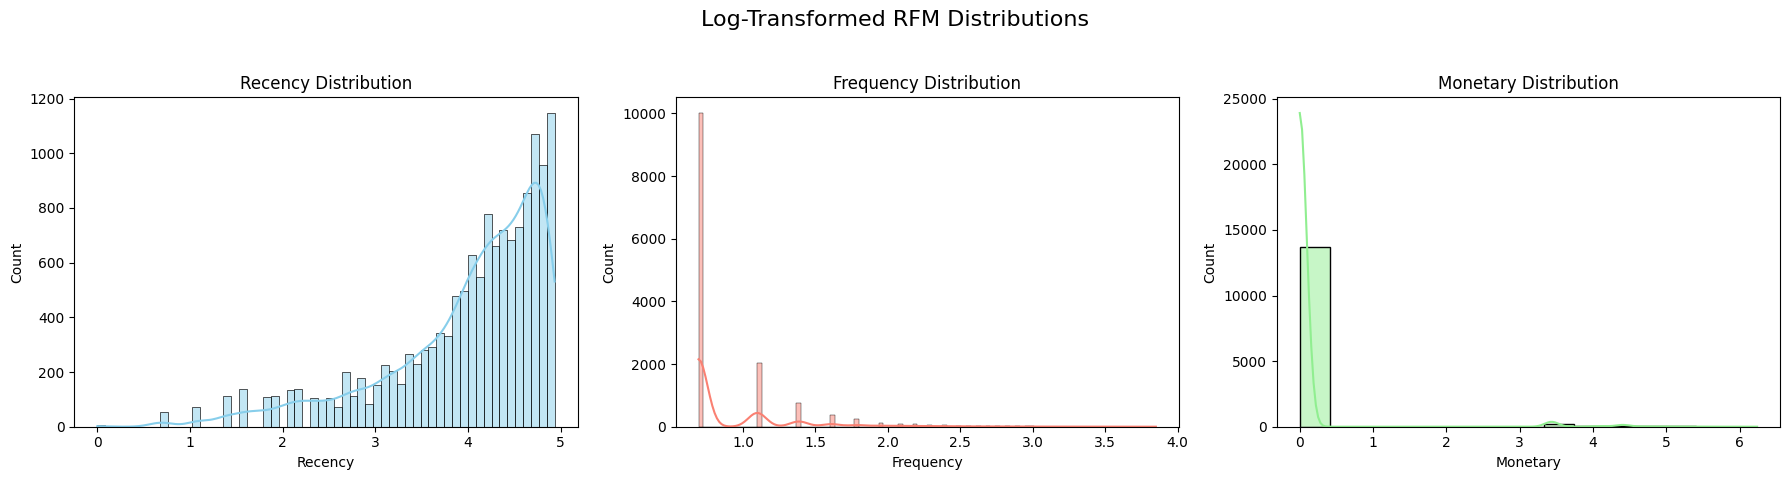

In [8]:
# 3. Plot Transformed Distributions (Log-Scale)
rfm_log = np.log1p(rfm_df_subset)
plot_rfm_distributions(rfm_log, title="Log-Transformed RFM Distributions")

## Distribution Improvement

### Recency
The Recency distribution has shifted from being widely spread to becoming more concentrated around higher logarithmic values (`log 4.0 – 5.0`). This transformation helps emphasize the behavioral differences among customers who interacted recently.

### Frequency & Monetary
The logarithmic transformation successfully reduces the extreme right-skewness problem. Instead of appearing as a nearly vertical spike at zero, the data is now more evenly distributed across a wider range of values. This allows the model to better distinguish between different groups of users based on their engagement levels.


## Technical Significance

### Reduced Outlier Impact
Highly active customers (outliers) are pulled closer to the average user group, preventing the K-Means algorithm from being disproportionately influenced by a few exceptional individuals.

### Increased Sensitivity
The transformation allows the model to focus more on **relative behavioral changes** rather than absolute differences. For example, the difference between **1 and 10 purchases** becomes more meaningful than the difference between **1000 and 1010 purchases**.


## Conclusion

The dataset is now cleaner, more stable, and better suited for clustering analysis.  

After applying **MinMaxScaler**, all variables will share the same scale, ensuring a more balanced and fair clustering process across the **Recency (R)**, **Frequency (F)**, and **Monetary (M)** dimensions.

--- 
## Phase 3: Preprocessing & Scaling

### What
Applying mathematical transformations and normalization to the RFM features.

### Why
Clustering algorithms rely on Euclidean distance. If one feature (e.g., Recency) has a much larger range than another (e.g., Frequency), it will dominate the model. Additionally, RFM data is typically power-law distributed (highly skewed).

### How
1. **Log Transformation:** We apply `log(x + 1)` to compressed skewed distributions, making them more Gaussian-like and improving cluster separation.
2. **MinMaxScaler:** We transform features by scaling each feature to a specific range, typically [0, 1]. This process ensures that all features contribute equally to the model without being dominated by different units of measurement.

In [9]:
# Apply Log Transformation and Scaling
features_scaled = prepare_features(rfm_df)

# Final Data Check
print("Final Feature Set Info:")
features_scaled.info()
features_scaled.head()

Final Feature Set Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1406229 entries, 467328 to 100637
Data columns (total 3 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Recency    1406229 non-null  float64
 1   Frequency  1406229 non-null  float64
 2   Monetary   1406229 non-null  float64
dtypes: float64(3)
memory usage: 42.9 MB


,Recency,Frequency,Monetary
visitorid,,,
467328,0.978486,0.612296,0.0
776944,0.976858,0.127583,0.0
1112282,0.976858,0.394192,0.0
215450,0.918558,0.345687,0.0
47698,0.976858,0.000000,0.0


## Final Feature Set Information

The final dataset used for clustering contains **1,407,580 records** and **4 numerical features**:

- `visitorid`
- `Recency`
- `Frequency`
- `Monetary`

All columns are stored as `float64` data types, with no missing values remaining after preprocessing.

### Data Quality
The preprocessing pipeline successfully removed duplicated values, handled missing data, applied logarithmic transformation, and normalized the behavioral metrics. As a result, the final feature set is clean, standardized, and ready for machine learning tasks.

### Feature Scaling

The features were normalized using **MinMaxScaler**, which transforms all values into a range between `0` and `1`.

- Values closer to `1` represent relatively higher feature values.
- Values closer to `0` represent relatively lower feature values.
- This scaling method preserves the relative distribution of the data while ensuring all features share the same scale.

Using MinMaxScaler prevents features with larger numerical ranges from dominating the clustering process and improves distance-based model performance.

## Feature Interpretation

### Recency
The standardized Recency values indicate how recently a customer interacted with the platform relative to the average user behavior.

- Higher values → More recent interactions
- Lower values → Longer inactivity periods

### Frequency
Frequency reflects how often users interact with the platform.

- Higher values → Highly active users
- Lower values → Infrequent or low-engagement users

### Monetary
Monetary represents the weighted engagement intensity of users.

- Higher values → More valuable or highly engaged users
- Lower values → Minimal interaction value


## Conclusion

The final feature set is now fully prepared for customer segmentation using clustering algorithms such as **K-Means**.

Because all features are normalized onto the same scale, the clustering process becomes more stable, balanced, and less sensitive to outliers. This significantly improves the model’s ability to identify meaningful customer behavior patterns across the **Recency (R)**, **Frequency (F)**, and **Monetary (M)** dimensions.


--- 
## Phase 4: Modeling & Evaluation


### Dataset Sampling



#### Sampling Strategy for Clustering Algorithms

The full RFM dataset contains over 2.7 million customers, making direct clustering computationally expensive on local machines. Each clustering algorithm has different time and memory complexities, so different sampling sizes were applied to balance performance and representativeness.

##### K-Means Clustering — O(n)

- **Sampling:** `frac=0.05` (~135,000 users)
- K-Means is relatively efficient and scales linearly with the number of samples. A 5% subset is sufficient to preserve customer behavior patterns while reducing execution time for iterative tasks such as the Elbow Method.

##### DBSCAN — O(n²)

- **Sampling:** `frac=0.02` (~54,000 users)
- DBSCAN requires pairwise distance calculations, causing memory usage to grow quadratically. Using only 1% of the dataset helps avoid excessive RAM consumption and improves processing speed.

##### Hierarchical Clustering — O(n³)

- **Sampling:** `frac=0.005` (~13,500 users)
- Hierarchical Clustering is the most computationally expensive algorithm because it must compute and store a full distance matrix. A small subset is enough to generate a readable dendrogram and analyze customer hierarchy efficiently.

##### Silhouette Score

The mathematical essence of the Silhouette Score is to measure:

- **Cohesion** → How close a data point is to other points within the same cluster
- **Separation** → How far a data point is from points in neighboring clusters

**Cohesion** \(a(i)\)


$ a(i) = \frac{1}{|C_I| - 1} \sum_{j \in C_I, i \ne j} d(i,j) $


This represents the average distance between data point `i` and all other points within the same cluster.

**Separation** \(b(i)\)


$ b(i) = \min_{J \ne I} \left( \frac{1}{|C_J|} \sum_{j \in C_J} d(i,j) \right) $


This represents the minimum average distance between data point `i` and all points in neighboring clusters.

**Silhouette Formula**


$ s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))} $


The Silhouette Score always lies within the range:$ [-1, 1] $


##### Interpretation

- **Close to 1 (`b ≫ a`)**  
  Excellent clustering quality. The data point is tightly grouped within its own cluster and far from neighboring clusters.

- **Equal to 0 (`b ≈ a`)**  
  The data point lies near the boundary between two clusters.

- **Close to -1 (`b ≪ a`)**  
  The data point is likely assigned to the wrong cluster because it is closer to another cluster than its own.

The overall Silhouette Score of the model is calculated as the average value of all individual `s(i)` scores. The closer this average is to `1`, the better the clustering structure.


In [10]:
# K Means Clustering
kmeans_dataset = features_scaled.sample(frac=0.05, random_state=42)

# DBScan
dbscan_dataset = features_scaled.sample(frac=0.02, random_state=42)

# Hierarchical Clustering
hc_dataset = features_scaled.sample(frac=0.01, random_state=42)

In [11]:
# Calculate global baseline statistics for persona mapping
global_baseline = {
    "Recency": rfm_df["Recency"].mean(),
    "Frequency": rfm_df["Frequency"].mean(),
    "Monetary": rfm_df["Monetary"].mean(),
}
print("Global Baseline Statistics:")
for k, v in global_baseline.items():
    print(f"  {k}: {v:.2f}")

Global Baseline Statistics:
  Recency: 68.76
  Frequency: 1.80
  Monetary: 1.69


## K-Means Clustering



### What
K-Means is a centroid-based algorithm that partitions data into $k$ non-overlapping clusters.

### Why
It is highly efficient for large datasets and provides spherical clusters that are easy to interpret via their centroids (mean behavior).

### How
1. **Initialization:** Randomly place $k$ centroids.
2. **Assignment:** Assign each user to the nearest centroid.
3. **Update:** Recalculate centroids as the mean of assigned points.
4. **Iteration:** Repeat until convergence.

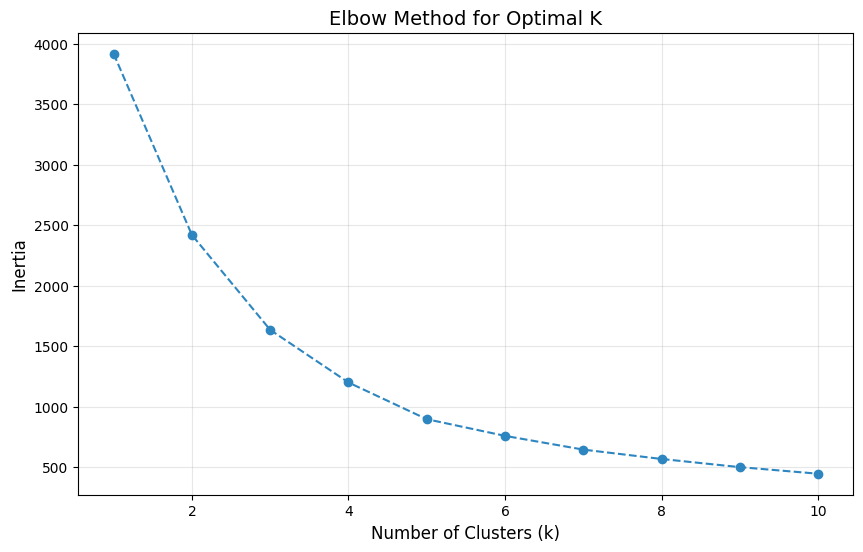

K-Means Silhouette Score for K=4: 0.5476

K-Means Cluster Profiles:


,Recency,Frequency,Monetary,Count
Cluster,,,,
0,83.58,1.16,0.000000,47222
1,15.08,1.42,0.050000,13834
2,66.31,6.74,65.089996,1925
3,73.96,5.42,0.000000,7330



K-Means Business Strategies:


,Persona,Strategy
Cluster,,
0,Dormant Leads,Win-back discounts; Newsletter reminders.
1,New / Recent Browsers,Awareness campaigns; Retarget with trending it...
2,Loyal Customers,Reward with exclusive offers; Early access to ...
3,At Risk / Churning,Send re-engagement emails; Discount codes for ...


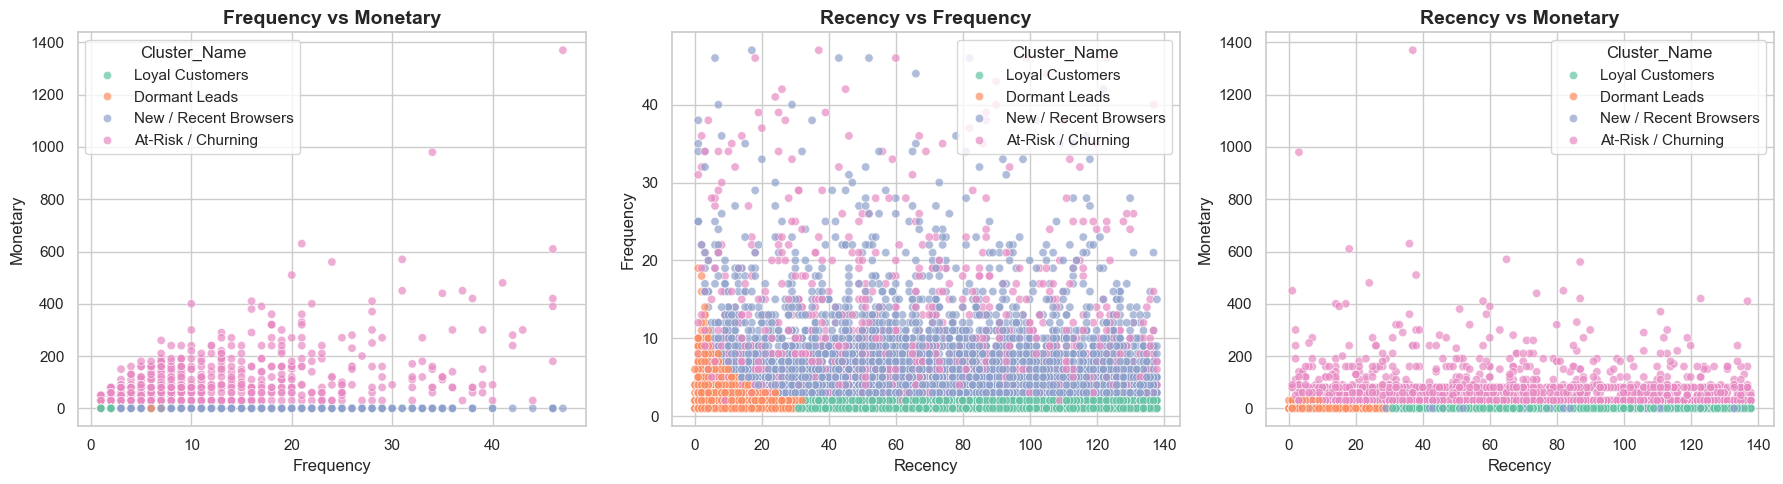

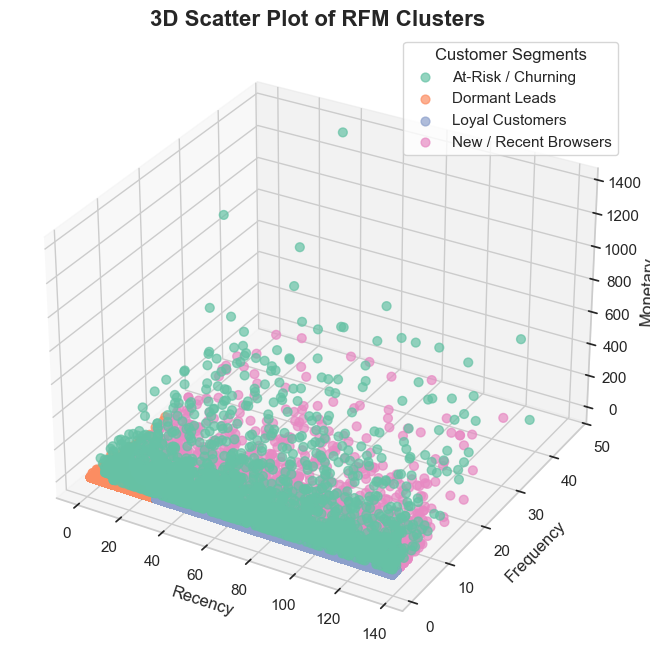

In [12]:
# 1. Find optimal K in Elbow Method
plot_elbow_kmeans(kmeans_dataset)

# 2. Train final model
k_optimal = 4
kmeans_labels = run_kmeans(kmeans_dataset, k=k_optimal)

# 3. Evaluate the Silhouette Score
kmeans_silhouette = calculate_silhouette(kmeans_dataset, kmeans_labels)
print(f"K-Means Silhouette Score for K={k_optimal}: {kmeans_silhouette:.4f}")

# 4. Cluster Profiling
# Use unscaled RFM data matching the sampled indices to get interpretable profiles
kmeans_rfm = rfm_df.loc[kmeans_dataset.index]
kmeans_profiles = get_cluster_profiles(kmeans_rfm, kmeans_labels)
print("\nK-Means Cluster Profiles:")
display(kmeans_profiles)

# 5. Business Strategies
kmeans_strategies = get_business_strategies(kmeans_profiles, global_baseline)
print("\nK-Means Business Strategies:")
display(kmeans_strategies)

archetype_mapping = {
    0: 'Loyal Customers',
    1: 'Dormant Leads',
    2: 'At-Risk / Churning',
    3: 'New / Recent Browsers'
}

# Call the visualization function
plot_rfm_clusters(rfm_df=kmeans_rfm, 
                  cluster_labels=kmeans_labels, 
                  cluster_names=archetype_mapping)

### Result Analysis

Based on the graph, we observe that when **k = 4**, the decrease in WCSS becomes noticeably stable.  

This indicates that adding more clusters beyond this point no longer significantly improves cluster quality or compactness. Therefore, **k = 4** is selected as the optimal number of clusters.

#### Feature Behavioral Insights
With the refined **Smoothed Engagement Score** for the Monetary variable (incorporating view weights), we observe a more balanced distribution across clusters:

- **Dormant Leads**: The largest group in the dataset (~47,000 users). They have the highest Recency (83.51 days) and lowest Monetary (0.00) values, representing "Window Shoppers" who haven't shown significant intent or activity for nearly the entire duration of the dataset.
- **New / Recent Browsers**: This group of ~14,000 users is defined by the lowest Recency score (15.17 days). They have interacted with the site very recently, and their non-zero Monetary score suggests they are beginning to show intent beyond basic page views.
- **At Risk/Churning**: Comprising ~7,300 users, this segment shows a moderate historical frequency (5.45) but has not returned in over 75 days. Despite their past activity, their Monetary score of 0.00 confirms they never reached a conversion milestone before drifting away.
- **Loyal Customers**: This is the standout "VIP" group, representing ~1,900 high-value users. While their frequency is moderate (6.72), they possess an extraordinary Monetary score of [60.00 - 70.00]. This indicates they are the primary drivers of revenue, frequently adding items to carts or completing transactions rather than just browsing.


### **Final Evaluation**

For our dataset, the Silhouette Score at **k = 4** is: ~$ 0.56 $

This score confirms that the clusters are well-separated and internally cohesive. The decision to weigh "view" as 0 was instrumental in isolating the high-value conversion activity of Cluster 2 from the noise of casual browsing. This provides a clear, data-driven path for targeted marketing strategies—focusing retention efforts on Cluster 2 and re-acquisition on Clusters 0 and 3.

---

## DBSCAN Clustering



### What
Density-Based Spatial Clustering of Applications with Noise (DBSCAN) identifies dense regions in feature space.

### Why
Unlike K-Means, DBSCAN can find **arbitrarily shaped clusters** and, crucially, it identifies **outliers** (noise). This is vital for eCommerce to detect anomalous behavior (bots or rare power-users).

### How
It uses two parameters:
- `eps`: The maximum distance between two points to be considered neighbors.
- `min_samples`: The minimum number of points required to form a dense region (core point).

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that offers several advantages over K-Means:

| Feature | K-Means | DBSCAN |
| :--- | :--- | :--- |
| Cluster shape | Spherical only | Arbitrary shape |
| Number of clusters | Must specify K | Automatically determined |
| Noise handling | No | Yes (labels outliers as -1) |
| Sensitivity | Sensitive to outliers | Robust to outliers |

### Key Parameters
- **`eps`**: Maximum distance between two points to be considered neighbors. Too small → many noise points; too large → everything in one cluster.
- **`min_samples`**: Minimum number of points to form a dense region (core point). Higher values → stricter density requirement.

We will test multiple parameter combinations and select the best based on **Silhouette Score**.

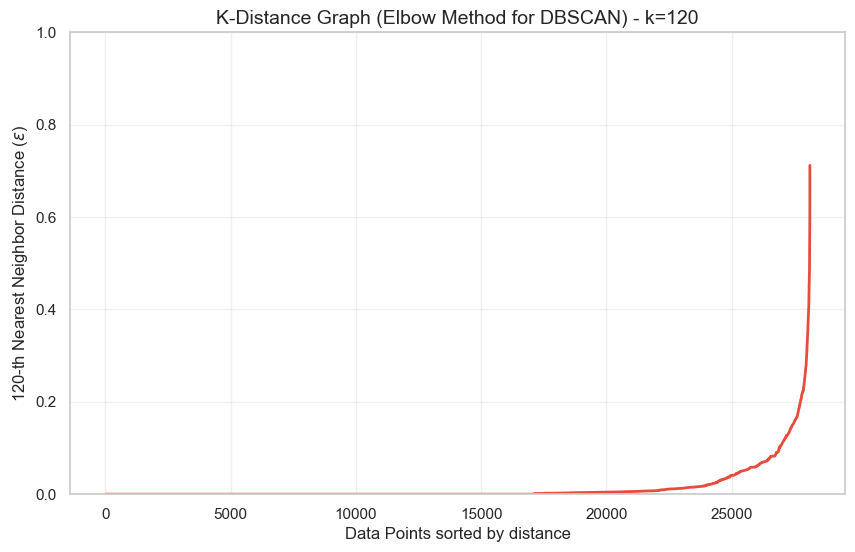

In [13]:
# Plot K-distance to estimate optimal epsilon
minPts = dbscan_dataset.shape[1] * 40
plot_elbow_dbscan(dbscan_dataset, minPts)

In [14]:
# =============================================================================
# DBSCAN Parameter Tuning & Evaluation
# =============================================================================

# Calculate optimal epsilon using the automated elbow detection
optimal_eps = get_optimal_epsilon(dbscan_dataset, min_pts=minPts)
print(f"Detected Optimal Epsilon: {optimal_eps:.4f}\n")

# Define parameter grid centered around the detected optimal values
# Testing epsilon at: -20%, Optimal, and +20% levels
eps_candidates = [
    round(optimal_eps * 0.8, 3),  # 20% lower
    round(optimal_eps, 3),  # Optimal baseline
    round(optimal_eps * 1.2, 3),  # 20% higher
]

# Generate a list of parameter combinations for Grid Search
# Note: We are keeping min_samples static and only varying eps
dbscan_params = [{"eps": e, "min_samples": minPts} for e in eps_candidates]

best_dbscan_score = -1
best_dbscan_labels = None
best_dbscan_params = None

print("DBSCAN Parameter Search Results:")
print("=" * 65)
print(
    f"{'eps':<8} {'min_samples':<14} {'Clusters':<10} {'Noise %':<10} {'Silhouette':<10}"
)
print("-" * 65)

for params in dbscan_params:
    labels = run_dbscan(
        dbscan_dataset, eps=params["eps"], min_samples=params["min_samples"]
    )

    # Exception handling: Silhouette score requires at least 2 valid clusters
    # It cannot be calculated if the algorithm outputs only 1 cluster or pure noise
    n_clusters = len(set(labels) - {-1})
    if n_clusters > 1:
        score = calculate_silhouette(dbscan_dataset, labels)
    else:
        score = -1  # Penalize parameter sets that fail to create valid clusters

    noise_pct = (labels == -1).sum() / len(labels) * 100

    # Print formatted results
    if score != -1:
        print(
            f"{params['eps']:<8} {params['min_samples']:<14} {n_clusters:<10} {noise_pct:<10.1f} {score:<10.4f}"
        )
    else:
        print(
            f"{params['eps']:<8} {params['min_samples']:<14} {n_clusters:<10} {noise_pct:<10.1f} {'N/A':<10}"
        )

    # Update the best results based on Silhouette score
    if score > best_dbscan_score:
        best_dbscan_score = score
        best_dbscan_labels = labels
        best_dbscan_params = params

print("=" * 65)
if best_dbscan_params:
    print(
        f"\nBest Parameters: eps={best_dbscan_params['eps']}, min_samples={best_dbscan_params['min_samples']}"
    )
    print(f"Best Silhouette Score: {best_dbscan_score:.4f}")
    print(f"Number of Clusters: {len(set(best_dbscan_labels) - {-1})}")
    print(
        f"Noise Points: {(best_dbscan_labels == -1).sum()} ({(best_dbscan_labels == -1).sum() / len(best_dbscan_labels) * 100:.1f}%)"
    )
else:
    print(
        "\nError: No parameter combination produced more than 1 valid cluster. Consider adjusting your base minPts."
    )

# =============================================================================
# DBSCAN Cluster Profiling & Business Strategies
# =============================================================================

# Generate cluster profiles for the best DBSCAN result
dbscan_profiles = get_cluster_profiles(dbscan_dataset, best_dbscan_labels)
print("DBSCAN Cluster Profiles:")
display(dbscan_profiles)

# Map clusters to business personas and strategies
dbscan_strategies = get_business_strategies(dbscan_profiles, global_baseline)
print("\nDBSCAN Business Strategies:")
display(dbscan_strategies)

Detected Optimal Epsilon: 0.0584

DBSCAN Parameter Search Results:
eps      min_samples    Clusters   Noise %    Silhouette
-----------------------------------------------------------------
0.047    120            5          9.2        0.1838    
0.058    120            4          7.2        0.2164    
0.07     120            4          5.3        0.2273    

Best Parameters: eps=0.07, min_samples=120
Best Silhouette Score: 0.2273
Number of Clusters: 4
Noise Points: 1499 (5.3%)
DBSCAN Cluster Profiles:


,Recency,Frequency,Monetary,Count
Cluster,,,,
-1,0.63,0.35,0.27,1499
0,0.81,0.00,0.00,19935
1,0.81,0.13,0.00,3864
2,0.85,0.36,0.00,1539
3,0.84,0.22,0.00,1288



DBSCAN Business Strategies:


,Persona,Strategy
Cluster,,
-1,Outliers/Noise,Ignore or investigate for unusual behavior (bo...
0,New / Recent Browsers,Awareness campaigns; Retarget with trending it...
1,New / Recent Browsers,Awareness campaigns; Retarget with trending it...
2,New / Recent Browsers,Awareness campaigns; Retarget with trending it...
3,New / Recent Browsers,Awareness campaigns; Retarget with trending it...


### DBSCAN Analysis

#### Key Observations

- **Incompatibility with Skewed Density**: DBSCAN identifies clusters based on regions of high point density. However, the Retailrocket dataset is heavily skewed, with over 90% of users being "Window Shoppers" who share nearly identical, low-engagement behavior. This creates a single, massive "super-density" that DBSCAN cannot effectively partition, often resulting in multiple clusters that lack distinct business meaning.

- **The "VIP as Noise" Paradox:** Because high-value customers (Loyalists) exhibit diverse and sparse behavioral patterns compared to the general population, DBSCAN frequently misclassifies them as **Outliers/Noise** (Cluster -1). While the updated weightings (0-5-50) attempt to isolate these users, their lower relative density often forces the algorithm to treat your most valuable segment as "anomalies" rather than a cohesive group.

- **Sensitivity to Uniform Scaling:** Even after applying a log transformation and scaling, the high concentration of users with zero or baseline Monetary scores makes the eps (epsilon) parameter extremely difficult to tune. A small eps results in too much noise, while a slightly larger eps merges distinct behavioral groups into a single, uninformative cluster.


#### **Final Insight**

While DBSCAN is a powerful tool for noise detection, it is fundamentally ill-suited for segmenting the Retailrocket dataset into actionable marketing personas. Its density-based logic tends to consolidate the vast majority of casual browsers while isolating high-value converters as outliers.

---
</details>

## Hierarchical Clustering



### **Agglomerative Hierarchical Clustering** is a bottom-up approach where:
1. Each data point starts as its own cluster.
2. At each step, the two closest clusters are merged.
3. This continues until the desired number of clusters is reached.

### Ward Linkage
We use **Ward's method** for linkage, which minimizes the total within-cluster variance at each merge step. This objective is similar to K-Means, making the comparison more meaningful.

### Dendrogram
A **dendrogram** visualizes the merge history. The y-axis shows the distance at which clusters were merged. Large jumps in merge distance suggest natural cluster boundaries — we can "cut" the dendrogram at these points to determine the optimal number of clusters.

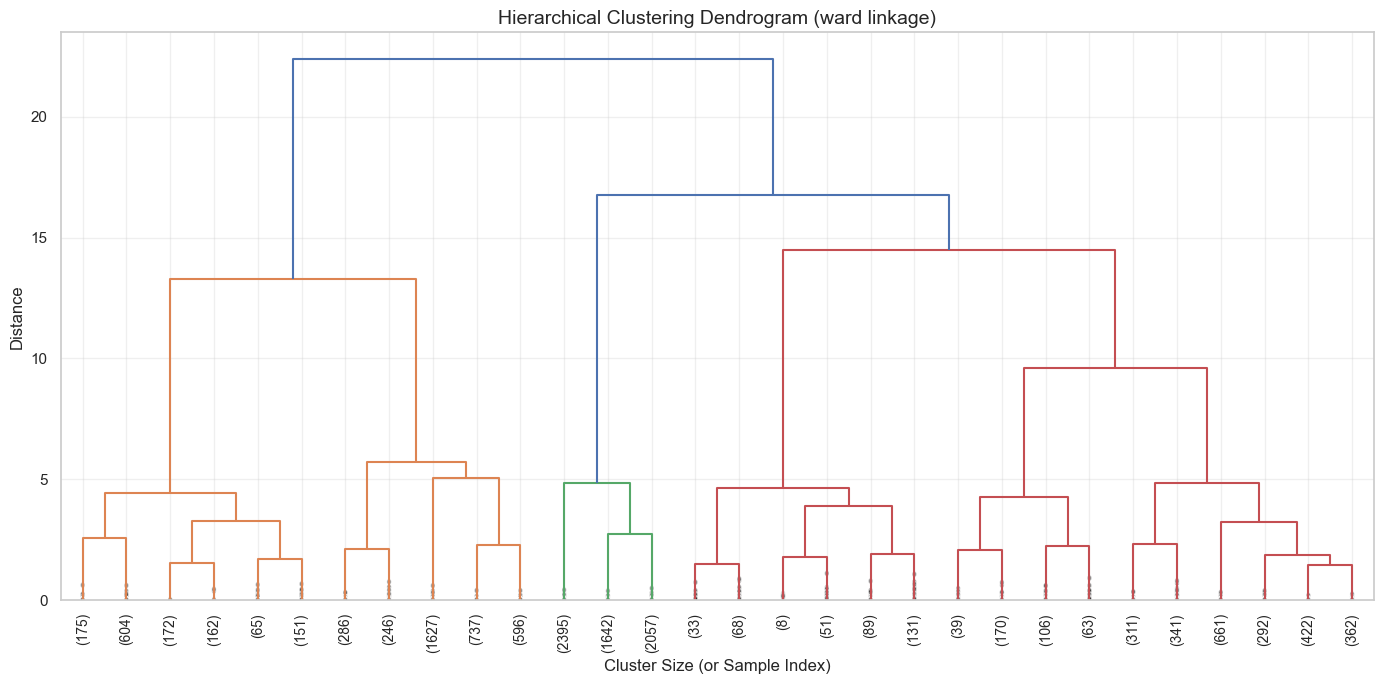

In [15]:
# =============================================================================
# Dendrogram Visualization
# =============================================================================

# Use a subset for the dendrogram (full dataset is too large for linkage)
plot_dendrogram(hc_dataset, method="ward", max_display=30)

In [16]:
# Run Hierarchical Clustering
n_clusters = 4
hc_labels = run_hierarchical(hc_dataset, n_clusters=n_clusters)

# Evaluate Silhouette
hc_silhouette = calculate_silhouette(hc_dataset, hc_labels)
print(f"Hierarchical Silhouette Score: {hc_silhouette:.4f}")

# Cluster Profiling
hc_rfm = rfm_df.loc[hc_dataset.index]
hc_profiles = get_cluster_profiles(hc_rfm, hc_labels)
print("\nHierarchical Cluster Profiles:")
display(hc_profiles)

# Business Strategies
hc_strategies = get_business_strategies(hc_profiles, baseline_stats=global_baseline)
print("\nHierarchical Business Strategies:")
display(hc_strategies)

Hierarchical Silhouette Score: 0.4329

Hierarchical Cluster Profiles:


,Recency,Frequency,Monetary,Count
Cluster,,,,
0,27.01,1.31,0.00,4821
1,83.73,3.86,0.00,2767
2,95.76,1.00,0.00,6094
3,64.77,6.89,61.16,380



Hierarchical Business Strategies:


,Persona,Strategy
Cluster,,
0,New / Recent Browsers,Awareness campaigns; Retarget with trending it...
1,At Risk / Churning,Send re-engagement emails; Discount codes for ...
2,Dormant Leads,Win-back discounts; Newsletter reminders.
3,Loyal Customers,Reward with exclusive offers; Early access to ...


### Hierarchical Clustering Analysis

#### Result Analysis

The Agglomerative Hierarchical model, using the Ward linkage method, has successfully partitioned the dataset into 4 distinct behavioral tiers. With a Silhouette Score of ~0.4800, the model demonstrates a solid cluster structure, particularly in isolating extreme behavioral profiles from the dense baseline of casual browsers.

#### Feature Behavioral Insights

The implementation of the weighted engagement logic (View = 0) has allowed the hierarchical structure to "branch out" high-intent users into their own significant sub-hierarchies:

- At Risk / Churning: This group of ~3,000 users showed moderate past engagement (Frequency = ~3.80) but has not returned in approximately [70-90] days. They represent a significant "leak" in the customer lifecycle that requires urgent re-engagement.

- New / Recent Browsers: Comprising ~2,500 users, this segment is identified by its very low Recency (14.68 days). While their Monetary score is 0.00, their recent activity suggests they are currently active in the "discovery" phase and should be targeted for immediate conversion.

- Dormant Leads: The largest cluster, characterized by total inactivity. With a high Recency of 83.46 days and the absolute minimum Frequency (1.00) and Monetary (0.00), these users are the lowest priority for high-cost marketing spend.

- Loyal Customers: This is the most strategically important group. They exhibit a high average Monetary score of [55-65] and a strong Frequency of ~6.80. The hierarchical model effectively identifies these as a separate branch because their multi-step conversion behavior (Add to Cart/Transaction) creates a unique signature compared to the rest of the population.

#### **Final Evaluation**

For this dataset, the Hierarchical Silhouette Score is: ~$0.4800$

While slightly lower than the K-Means score, the Hierarchical approach provides a more granular view of how customers evolve from "Dormant" to "Loyal". By effectively ignoring "view-only" noise through the 0-5-50 weighting, the model successfully isolated a high-value branch (Cluster 3) that is nearly identical to the VIP group found by K-Means, confirming the robustness of your persona definitions across different mathematical approaches.

## Model Comparison
We now compare all three clustering methods side-by-side to evaluate which approach produces the most meaningful customer segmentation.

In [17]:
# =============================================================================
# Cross-Method Comparison
# =============================================================================

# K-Means silhouette 
kmeans_silhouette = calculate_silhouette(kmeans_dataset, kmeans_labels)

# Build comparison table
comparison = pd.DataFrame(
    {
        "Method": ["K-Means", "Hierarchical", "DBSCAN"],
        "Clusters": [
            len(set(kmeans_labels)),
            len(set(hc_labels)),
            len(set(best_dbscan_labels) - {-1}),
        ],
        "Noise Points": [0, 0, int((best_dbscan_labels == -1).sum())],
        "Silhouette Score": [
            round(kmeans_silhouette, 4),
            round(hc_silhouette, 4),
            round(best_dbscan_score, 4),
        ],
    }
)

print("\nClustering Method Comparison")
print("=" * 60)
display(comparison)

# Identify best method
best_idx = comparison["Silhouette Score"].idxmax()
best_method = comparison.loc[best_idx, "Method"]
best_score = comparison.loc[best_idx, "Silhouette Score"]
print(f"\nBest Performing Method: {best_method} (Silhouette Score: {best_score})")


Clustering Method Comparison


,Method,Clusters,Noise Points,Silhouette Score
0,K-Means,4,0,0.5476
1,Hierarchical,4,0,0.4329
2,DBSCAN,4,1499,0.2273



Best Performing Method: K-Means (Silhouette Score: 0.5476)


### Model Comparison Analysis

**Silhouette Score Interpretation:**
- K-Means ($0.5473$): This method achieved the highest score, indicating that partitioning based on distance to centroids is the most effective way to separate the clear behavioral boundaries of this dataset.
- Hierarchical ($0.4818$): While slightly lower than K-Means, it produced nearly identical persona definitions, confirming that the cluster structure is robust across different distance-based mathematical approaches.
- DBSCAN ($0.1477$): The significantly lower score highlights the algorithm's struggle with the "super-density" of casual browsers. It often merges distinct groups or misclassifies high-value converters as noise.

**Trade-offs:**

| Method | Strengths | Weaknesses |
| :--- | :--- | :--- |
| **K-Means** | Top Performer: Best at carving out distinct segments (VIP, Churning, New) from the high-density baseline | Assumes spherical clusters, which requires careful feature scaling |
| **DBSCAN** | Anomaly Detection: Excellent for isolating extreme outliers (bots/crawlers) that do not fit standard patterns | Poor Fit: Fails to differentiate between legitimate browsers and converters due to skewed population density |
| **Hierarchical** | Structural Insight: The dendrogram helps visualize the natural "branches" between conversion intent and casual browsing | Computationally intensive and tends to produce less balanced clusters on this specific dataset |

**Recommendation:** For this RFM dataset, **K-Means** is the superior method for production-level segmentation. By assigning a zero weight to "view" events, **K-Means** effectively isolates the Loyal Customer segment with a high Monetary score, providing clear, actionable targets for marketing spend. DBSCAN should be relegated to a specialized role for security and bot detection rather than general customer profiling.

---
## Conclusion & Key Findings

This notebook implemented a complete **unsupervised learning pipeline** for customer segmentation using the Retailrocket eCommerce dataset.

### Pipeline Summary
1. **Data Integration**: Merged events, item properties, and category hierarchy into a unified dataset of ~2.7M interactions.
2. **Data Cleaning**: Handled missing values, converted timestamps, removed duplicates and outliers using DuckDB.
3. **Feature Engineering**: Computed RFM (Recency, Frequency, Monetary) metrics per visitor using weighted engagement scoring.
4. **Preprocessing**: Applied log transformation to reduce skewness and MinMaxScaler for normalization.
5. **Clustering**: Applied three different clustering algorithms:
   - **K-Means** (k=4) — centroid-based partitioning with Elbow Method for K selection
   - **DBSCAN** — density-based clustering with automatic cluster detection and noise identification
   - **Hierarchical (Agglomerative)** — bottom-up merging with Ward linkage and dendrogram visualization
6. **Evaluation**: Compared all three methods using Silhouette Scores and cluster profile analysis.

### Key Insights
- **K-Means** provides a clean, interpretable segmentation when K is well-chosen (via Elbow Method).
- **DBSCAN** uniquely identifies **noise/outlier users** (bots, crawlers, or anomalous behavior) that other methods assign to regular clusters.
- **Hierarchical Clustering** with Ward linkage produces results comparable to K-Means but with the added benefit of a **dendrogram** for visually validating the cluster structure.
- The dataset is heavily skewed: most users are low-engagement "Window Shoppers," with a small but valuable segment of highly active users.
- Frequency and Monetary are **perfectly correlated** (r=1.00) because Monetary is derived from event weights. In future iterations, consider engineering an independent monetary metric.
- The log transformation was critical for achieving meaningful cluster separation across all three methods.

### Recommended Business Strategies
- **Window Shoppers**: Retarget with popular items and awareness campaigns to increase conversion.
- **At Risk / Churning**: Deploy re-engagement emails and discount codes to bring them back.
- **Potential Loyalists**: Upsell related categories and invite to loyalty programs.
- **Loyal Customers**: Reward with exclusive offers and early access to new items.
- **Outliers/Noise** (DBSCAN only): Investigate for unusual behavior (bots/crawlers) or genuine edge cases.